In [40]:
!pip install networkx
!pip install ortools

#**Exercício 1, Distribuição de Encomendas**

**Este problema usa optimização MIP (“Mixed Integer Programming” (OrTools) e representação por  Grafos ( NetworkX).**


1. Para um distribuidor de encomendas o seu território está organizados em pontos (“nodes”) de fornecimento (“sources”), pontos de passagem  e pontos de entrega (“sinks”) ligados por vias de comunicação (“edges”) bidirecionais cada uma das quais associada uma capacidade em termos do número de veículos de transporte que suporta.
2. Os items distribuidos estão organizados em “pacotes” de três tipos “standard” : uma unidade, duas unidades e cinco unidades. Os pacotes são transportados em veículos todos com a capacidade de 10 unidades. Cada ponto de entrega tem um limite no número total de unidades que tem em “stock” e um limite no número de veículos que dispõe.
3. Cada encomenda é definida por o identificador do ponto de entrega e pelo número de pacotes, de cada um dos tipos, que devem ser entregues nesse ponto.
4. O objetivo do problema é decidir, a partir de uma encomenda e com um mínimo no número de veículos,
        - em cada ponto de entrega,  se estará envolvido no fornecimento de unidades que essa encomenda requer sem violar os limites do seu “stock”.
        - em cada ponto de entrega,   como empacotar as unidades disponíveis, de acordo com a encomenda”,  e como as distribuir por veículos,
        - em cada veículo, qual o percurso a seguir até  ao ponto de entrega; para cada via ao longo de cada percurso, o total de veículos não pode exceder a capacidade dessa via.


## **Resolução do Exercício 1**

### Explicação da Função `resolver_distribuicao`

A função `resolver_distribuicao` tem como objetivo **otimizar a distribuição de pacotes numa rede de transporte**, minimizando o número total de veículos necessários.  
Para isso, utiliza as bibliotecas **`networkx`** (para modelar a rede como um grafo) e **`ortools`** (para formular e resolver o problema de otimização inteira mista).

---

### 1. Estrutura Geral do Problema

O problema é modelado como um **grafo dirigido e capacitado**, em que:
- Os **nós** representam pontos de fornecimento, passagem ou entrega.
- As **arestas** representam as ligações entre esses pontos, com uma capacidade máxima de veículos simultâneos.

A função considera:
- Um conjunto de **pacotes** a entregar, cada um com origem, destino e tamanho.
- Um conjunto de **veículos**, cada um com capacidade máxima de transporte.
- Um conjunto de **restrições** que asseguram a coerência das entregas e respeitam os limites do grafo.

---

### 2. Entradas da Função

| Parâmetro | Tipo | Descrição |
|------------|------|------------|
| `grafo` | `networkx.Graph` | Representa a rede de distribuição, com nós e arestas (com capacidade). |
| `pacotes` | `list[tuple]` | Lista de pacotes, onde cada elemento é `(tamanho, origem, destino)`. |
| `stock_sink` | `dict` | Dicionário que define o stock máximo permitido em cada ponto de entrega. |

---

### 3. Variáveis de Decisão

A formulação utiliza **variáveis binárias** para representar decisões discretas sobre o uso de veículos, pacotes e caminhos.

| Variável | Tipo | Significado |
|-----------|------|-------------|
| `x[v]` | Binária | Indica se o veículo `v` é utilizado (`1`) ou não (`0`). |
| `y[i, v]` | Binária | Indica se o pacote `i` é atribuído ao veículo `v`. |
| `z[i, v, k]` | Binária | Indica se o pacote `i`, transportado pelo veículo `v`, utiliza o `k`-ésimo caminho possível entre origem e destino. |
| `w[v, j]` | Binária | Indica se o veículo `v` utiliza a `j`-ésima aresta do grafo. |

---

### 4. Restrições do Modelo

As restrições asseguram a consistência e viabilidade da solução:

1. **Atribuição dos Pacotes**  
   Cada pacote deve ser transportado por exatamente um veículo:
   \[
   \sum_v y[i, v] = 1, \quad \forall i
   \]

2. **Capacidade dos Veículos**  
   A soma dos tamanhos dos pacotes num mesmo veículo não pode exceder 10 unidades:
   \[
   \sum_i tamanho_i \cdot y[i, v] \leq 10, \quad \forall v
   \]

3. **Seleção de Caminho**  
   Se um pacote é atribuído a um veículo, ele deve seguir **exatamente um caminho** entre a origem e o destino.

4. **Utilização de Arestas**  
   Se um veículo utiliza um caminho, ele deve utilizar **todas as arestas** que compõem esse caminho.

5. **Capacidade das Arestas**  
   O número de veículos a usar uma mesma aresta não pode ultrapassar a capacidade máxima da aresta.

6. **Limite de Stock nos Sinks**  
   O total de unidades entregues em cada nó destino não pode ultrapassar o stock máximo definido:
   \[
   \sum_{i \text{ com destino } = j} tamanho_i \leq stock\_sink[j]
   \]

---

### 5. Função Objetivo

Minimizar o número total de veículos utilizados:

\[
\text{minimizar } \sum_v x[v]
\]

---

### 6. Método de Resolução

A função utiliza o **solver SCIP** do OR-Tools para resolver o modelo de **otimização inteira mista (MIP)**.  
O solver analisa o espaço de soluções possíveis respeitando as restrições impostas, e tenta encontrar a **solução ótima** — isto é, a configuração com o **menor número de veículos ativos**.

---

### 7. Saída da Função

O output inclui:

- O **status da otimização** (por exemplo, se uma solução ótima foi encontrada).
- O **número total de veículos utilizados**.
- Os **detalhes de cada veículo**, incluindo:
  - Quais pacotes transporta.
  - Que caminhos utiliza dentro do grafo.

---

### 8. Resumo do Fluxo da Função

```text
Construção do grafo (NetworkX)
        ↓
Definição das variáveis binárias (x, y, z, w)
        ↓
Criação das restrições de capacidade e stock
        ↓
Formulação da função objetivo (minimizar veículos)
        ↓
Resolução com solver SCIP (ORTools)
        ↓
Apresentação dos resultados (status, veículos, caminhos)


In [ ]:
import networkx as nx
from ortools.linear_solver import pywraplp

def resolver_distribuicao(grafo, pacotes, stock_sink,debug=False):
    """
    Resolve o problema de distribuição de pacotes num grafo com restrições de capacidade e stock.

    Args:
        grafo: Objeto networkx.Graph representando a rede de distribuição.
        pacotes: Lista de tuplos (tamanho, origem, destino) representando os pacotes a distribuir.
        stock_sink: Dicionário com o stock máximo para cada sink (ponto de entrega).
        debug: Boleano para ativar definições de debug

    Returns:
        Um dicionário com os resultados da otimização ou None se não houver solução ótima.
    """
    caminhos_por_pacote = []
    for (tam, s, t) in pacotes:
        caminhos = list(nx.all_simple_paths(grafo, source=s, target=t))
        caminhos_por_pacote.append(caminhos)

    if debug:
      print(f"Caminhos que cada pacote pode seguir:{caminhos_por_pacote}")

    solver = pywraplp.Solver.CreateSolver("SCIP")
    num_veiculos = len(pacotes)  # limite superior (cada pacote num veiculo)

    # x[v]: variável binária = 1 se o veículo v é usado, 0 caso contrário
    x = [solver.BoolVar(f"x[{v}]") for v in range(num_veiculos)]
    # y[i, v]: variável binária = 1 se o pacote i é atribuído ao veículo v, 0 caso contrário
    y = [[solver.BoolVar(f"y[{i},{v}]") for v in range(num_veiculos)] for i in range(len(pacotes))]
    # z[i, v, k]: variável binária = 1 se o pacote i no veículo v usa o k-ésimo caminho possível, 0 caso contrário
    z = [[[solver.BoolVar(f"z[{i},{v},{k}]")
           for k in range(len(caminhos_por_pacote[i]))]
          for v in range(num_veiculos)] for i in range(len(pacotes))]

    # R1 Cada pacote vai exatamente para um veículo
    for i in range(len(pacotes)):
        solver.Add(sum(y[i][v] for v in range(num_veiculos)) == 1)

    # R2 Capacidade de cada veículo tem de ser obedecida
    capacidade_veiculo = 10
    for v in range(num_veiculos):
        solver.Add(sum(pacotes[i][0] * y[i][v] for i in range(len(pacotes))) <= capacidade_veiculo * x[v])

    # R3 Se um pacote i está no veículo v → escolhe exatamente um caminho
    for i in range(len(pacotes)):
        for v in range(num_veiculos):
            solver.Add(sum(z[i][v][k] for k in range(len(caminhos_por_pacote[i]))) == y[i][v])

    # R4 Capacidade das arestas
    arestas = list(grafo.edges())
    num_arestas = len(arestas)

    if debug:
      print(f"Arestas do Grafo:{arestas}")

    # criar variáveis w[v][j] = 1 se veículo v usa a aresta j
    w = [[solver.BoolVar(f"w[{veic},{j}]") for j in range(num_arestas)] for veic in range(num_veiculos)]

    # se veículo não é usado, w deve ser 0
    for veic in range(num_veiculos):
        for j in range(num_arestas):
            solver.Add(w[veic][j] <= x[veic])

    # se algum pacote i no veículo v escolher um caminho k que usa a aresta j,
    # w[v][j] deve ser 1 (ou seja, w >= z)
    caminho_usa_arestas = []
    for i, caminhos in enumerate(caminhos_por_pacote):
        lista_por_caminho = []
        for caminho in caminhos:
            indices = []
            for a, b in zip(caminho[:-1], caminho[1:]):
                for j, e in enumerate(arestas):
                    if set(e) == set((a, b)):
                        indices.append(j)
                        break
            lista_por_caminho.append(indices)
            if debug:
              print(f"Todos os indices de caminhos que a encomenda {i} pode seguir {lista_por_caminho},indices dos caminhos que usa {indices}")
        caminho_usa_arestas.append(lista_por_caminho)
        if debug:
          print(f"Todos os indices que todas os pacotes podem seguir:")
          for i,coiso in enumerate(caminho_usa_arestas):
            print(f"Caminhos possíveis no {i}º pacote: {coiso}")

    # obriga a quando um pacote vai num caminho, o carro que o leva também o vá
    # constraint: w >= z para cada combinação relevante
    for i in range(len(pacotes)):
        for veic in range(num_veiculos):
            for k, indices_arestas in enumerate(caminho_usa_arestas[i]):
                for j in indices_arestas:
                    # se pacote i no veículo veic escolher caminho k que passa pela aresta j,
                    # então w[veic][j] >= z[i][veic][k]
                    solver.Add(w[veic][j] >= z[i][veic][k])

    # capacidade por aresta em termos de veículos
    for j, (u, v) in enumerate(arestas):
        cap = grafo[u][v]["capacidade"]
        solver.Add(sum(w[veic][j] for veic in range(num_veiculos)) <= cap)


    # R5 Stock máximo nos sinks
    for sink in stock_sink:
        total_demandado_sink = sum(tam for tam, s, t in pacotes if t == sink)
        solver.Add(total_demandado_sink <= stock_sink[sink])
        print(f"Stock máximo para {sink}: {stock_sink[sink]}, total demandado: {total_demandado_sink}")

    solver.Minimize(sum(x[v] for v in range(num_veiculos)))

    status = solver.Solve()
    print(f"Solver status: {status}")

    if status == pywraplp.Solver.OPTIMAL:
        resultados = {
            "status": "Ótimo encontrado",
            "total_veiculos": int(solver.Objective().Value()),
            "detalhes_veiculos": []
        }
        carroCount = 1
        for v in range(num_veiculos):
            if x[v].solution_value() > 0.5:
                pacotes_no_v = []
                caminhos_usados = []
                for i in range(len(pacotes)):
                    if y[i][v].solution_value() > 0.5:
                        pacotes_no_v.append(pacotes[i])
                        for k, caminho in enumerate(caminhos_por_pacote[i]):
                            if z[i][v][k].solution_value() > 0.5:
                                caminhos_usados.append(caminho)
                resultados["detalhes_veiculos"].append({
                    "veiculo": carroCount,
                    "pacotes": pacotes_no_v,
                    "caminhos": caminhos_usados
                })
                carroCount+=1
        return resultados
    else:
        print("Não foi encontrada uma solução ótima.")
        print(f"Status code: {status}")
        return None

In [ ]:
def printResultados(resultado):
    print("\nResultado:")
    print(f"Status: {resultado['status']}")
    print(f"Total de veículos necessários: {resultado['total_veiculos']}")
    for detalhe in resultado['detalhes_veiculos']:
        print(f"  Veículo {detalhe['veiculo']}:")
        print(f"    Pacotes: {detalhe['pacotes']}")
        print(f"    Caminhos: {detalhe['caminhos']}")

### Exemplo Simples (4 nodos, 4 arestas):

Stock máximo para Sink: 20, total demandado: 16
Solver status: 0

Resultado:
Status: Ótimo encontrado
Total de veículos necessários: 2
  Veículo 1:
    Pacotes: [(2, 'Source', 'Sink'), (2, 'Source', 'Sink'), (2, 'Source', 'Sink')]
    Caminhos: [['Source', 'edge2', 'Sink'], ['Source', 'edge2', 'Sink'], ['Source', 'edge2', 'Sink']]
  Veículo 2:
    Pacotes: [(5, 'Source', 'Sink'), (5, 'Source', 'Sink')]
    Caminhos: [['Source', 'egde1', 'Sink'], ['Source', 'egde1', 'Sink']]


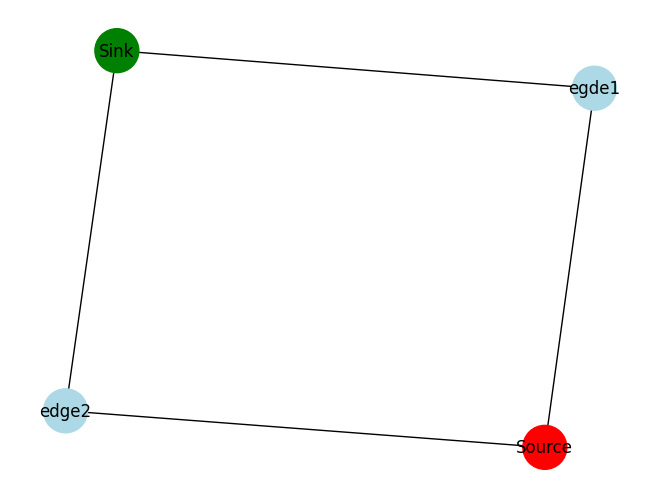

In [ ]:
# Exemplo simples
G = nx.Graph()
G.add_node("Source", cor = "red")
G.add_node("egde1",cor = "lightblue")
G.add_node("edge2",cor = "lightblue")
G.add_node("Sink",cor = "green")
G.add_edge("Source", "egde1", capacidade=1)
G.add_edge("egde1", "Sink", capacidade=1)
G.add_edge("Source", "edge2", capacidade=1)
G.add_edge("edge2", "Sink", capacidade=1)

color_map = []
for node in G:
  color_map.append(G.nodes[node]['cor'])

nx.draw(G,with_labels=True,node_color=color_map,node_size=1000)

pacotes_exemplo = [
    (5, "Source", "Sink"),
    (5, "Source", "Sink"),
    (2, "Source", "Sink"),
    (2, "Source", "Sink"),
    (2, "Source", "Sink")
]

stock_sink_exemplo = {"Sink": 20}

resultado_otimizacao = resolver_distribuicao(G, pacotes_exemplo, stock_sink_exemplo)

if resultado_otimizacao:
    printResultados(resultado_otimizacao)

---
### Exemplo Médio (7 nodos, 10 arestas)

Nodes: [('S1', {'tipo': 'source', 'cor': 'red'}), ('S2', {'tipo': 'source', 'cor': 'red'}), ('P1', {'tipo': 'passagem', 'cor': 'lightblue'}), ('P2', {'tipo': 'passagem', 'cor': 'lightblue'}), ('P3', {'tipo': 'passagem', 'cor': 'lightblue'}), ('T1', {'tipo': 'sink', 'cor': 'green'}), ('T2', {'tipo': 'sink', 'cor': 'green'})]
Edges: [('S1', 'P1', {'capacidade': 3}), ('S1', 'P2', {'capacidade': 2}), ('S2', 'P1', {'capacidade': 4}), ('S2', 'P3', {'capacidade': 3}), ('P1', 'P2', {'capacidade': 1}), ('P1', 'T1', {'capacidade': 5}), ('P2', 'P3', {'capacidade': 2}), ('P2', 'T1', {'capacidade': 3}), ('P3', 'T1', {'capacidade': 2}), ('P3', 'T2', {'capacidade': 4})]
[{'tamanho': 5, 'origem': 'S1', 'destino': 'T1'}, {'tamanho': 5, 'origem': 'S1', 'destino': 'T1'}, {'tamanho': 2, 'origem': 'S1', 'destino': 'T2'}, {'tamanho': 2, 'origem': 'S2', 'destino': 'T1'}, {'tamanho': 1, 'origem': 'S2', 'destino': 'T2'}, {'tamanho': 5, 'origem': 'S1', 'destino': 'T2'}, {'tamanho': 2, 'origem': 'S2', 'destino':

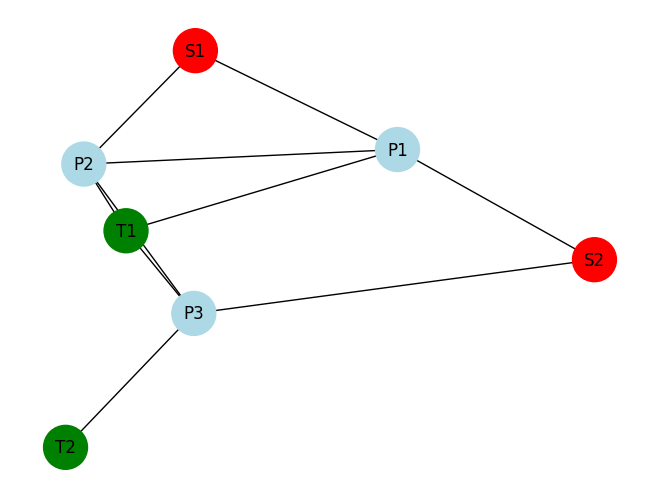

In [ ]:
import networkx as nx

# Create a new empty graph object
G_large = nx.Graph()

# Add multiple nodes representing sources, intermediate points, and sinks
G_large.add_node("S1", tipo="source", cor = "red")
G_large.add_node("S2", tipo="source", cor = "red")
G_large.add_node("P1", tipo="passagem", cor = "lightblue")
G_large.add_node("P2", tipo="passagem", cor = "lightblue")
G_large.add_node("P3", tipo="passagem", cor = "lightblue")
G_large.add_node("T1", tipo="sink", cor = "green")
G_large.add_node("T2", tipo="sink", cor = "green")

# Add multiple edges connecting these nodes with capacities
G_large.add_edge("S1", "P1", capacidade=3)
G_large.add_edge("S1", "P2", capacidade=2)
G_large.add_edge("S2", "P1", capacidade=4)
G_large.add_edge("S2", "P3", capacidade=3)
G_large.add_edge("P1", "P2", capacidade=1)
G_large.add_edge("P1", "T1", capacidade=5)
G_large.add_edge("P2", "P3", capacidade=2)
G_large.add_edge("P2", "T1", capacidade=3)
G_large.add_edge("P3", "T1", capacidade=2)
G_large.add_edge("P3", "T2", capacidade=4)

# Print the nodes and edges
color_map = []
for node in G_large:
  color_map.append(G_large.nodes[node]['cor'])
nx.draw(G_large,with_labels=True,node_color=color_map,node_size=1000)
print("Nodes:", G_large.nodes(data=True))
print("Edges:", G_large.edges(data=True))

pacotes_grandes_exemplo = [
    {"tamanho": 5, "origem": "S1", "destino": "T1"},
    {"tamanho": 5, "origem": "S1", "destino": "T1"},
    {"tamanho": 2, "origem": "S1", "destino": "T2"},
    {"tamanho": 2, "origem": "S2", "destino": "T1"},
    {"tamanho": 1, "origem": "S2", "destino": "T2"},
    {"tamanho": 5, "origem": "S1", "destino": "T2"},
    {"tamanho": 2, "origem": "S2", "destino": "T1"},
    {"tamanho": 1, "origem": "S1", "destino": "T1"},
    {"tamanho": 5, "origem": "S2", "destino": "T2"},
    {"tamanho": 2, "origem": "S1", "destino": "T1"},
    {"tamanho": 1, "origem": "S2", "destino": "T2"},
    {"tamanho": 5, "origem": "S1", "destino": "T1"},
    {"tamanho": 2, "origem": "S2", "destino": "T2"},
    {"tamanho": 1, "origem": "S1", "destino": "T1"},
    {"tamanho": 5, "origem": "S2", "destino": "T2"},
]

print(pacotes_grandes_exemplo)

stock_sinks_grandes_exemplo = {
    "T1": 30,
    "T2": 25
}

resultado_otimizacao_grande = resolver_distribuicao(G_large, [(p['tamanho'], p['origem'], p['destino']) for p in pacotes_grandes_exemplo], stock_sinks_grandes_exemplo)

print("\nResultado da Otimização Grande Exemplo:")
if resultado_otimizacao_grande:
  printResultados(resultado_otimizacao_grande)

### **Exemplo Gigante (20 arestas, +/- 60 arestas (gerado aleatóriamente))**

Para este exemplo, notamos que a função original não consegue resolver em tempo ótimo, logo tivemos de adaptá-la de modo a conseguir suportar exemplos muito grandes.

#### Explicação da Função `resolver_distribuicao_melhorado`

Esta função é uma versão otimizada da função `resolver_distribuicao` para lidar com grafos e encomendas de maior dimensão, melhorando a performance e a escalabilidade da resolução do problema de distribuição. As principais diferenças e estratégias de otimização aplicadas são:

1.  **Limite de Caminhos por Pacote (`max_paths_per_package`)**: Em vez de considerar todos os caminhos possíveis entre origem e destino para cada pacote (o que pode crescer exponencialmente em grafos maiores), esta versão limita o número de caminhos considerados aos `k` caminhos mais curtos (onde `k` é definido por `max_paths_per_package`). Isso reduz significativamente o número de variáveis de decisão (`z`) e restrições, tornando o problema mais tratável para o solver. A função utiliza `nx.shortest_simple_paths` para encontrar estes caminhos de forma eficiente.
2.  **Limite de Comprimento de Caminho (`max_path_length`)**: Permite opcionalmente descartar caminhos que excedam um determinado número de "saltos" (`hops`). Isso pode ser útil em redes onde caminhos muito longos são indesejáveis ou ineficientes, reduzindo ainda mais o espaço de busca por caminhos.
3.  **Bound Realista para o Número de Veículos**: Em vez de usar o número total de pacotes como um limite superior (que pode ser demasiado alto para muitos pacotes pequenos num mesmo veículo), esta versão utiliza um limite superior mais apertado calculado com base na capacidade total de unidades a transportar e a capacidade de cada veículo (`ceil(total_unidades / capacidade_veiculo)`). Embora o `num_veiculos` ainda não seja fixo (o objetivo é minimizá-lo), este bound inicial pode ajudar o solver a encontrar a solução mais rapidamente.
4.  **Quebra de Simetria (`x[v] >= x[v+1]`)**: Adiciona restrições que forçam os veículos a serem "usados por ordem". Isto significa que o solver é incentivado a usar o veículo 0 antes do veículo 1, o veículo 1 antes do veículo 2, e assim por diante. Esta técnica ajuda a reduzir a simetria no modelo, o que pode acelerar o processo de resolução para alguns solvers MIP.
5.  **Time Limit para o Solver (`time_limit_seconds`)**: Define um tempo máximo para o solver procurar uma solução. Em problemas complexos que podem demorar muito tempo a resolver até à otimalidade garantida, um time limit permite obter uma solução factível (não necessariamente a ótima) dentro de um tempo aceitável.
6.  **Tratamento de Inviabilidade Precoce**: Adiciona verificações iniciais para detetar se algum pacote não tem caminho entre a origem e o destino (ou não tem caminhos que satisfaçam os filtros de comprimento). Se um pacote não tiver caminho, o problema é inviável, e a função retorna `None` imediatamente, evitando tentativas de resolução que falhariam.
7.  **Utilização de `round()` para Variáveis Binárias**: Ao extrair a solução, utiliza `round()` nas variáveis de decisão binárias (`x`, `y`, `z`) para mitigar pequenos erros de ponto flutuante que podem ocorrer durante o processo de otimização e que fariam com que valores muito próximos de 0 ou 1 fossem interpretados incorretamente.

Estas otimizações são particularmente importantes quando se lida com grafos maiores ou um grande número de pacotes, pois a complexidade dos problemas de otimização inteira mista pode crescer rapidamente com o número de variáveis e restrições. A versão melhorada tenta manter o problema mais manejável para o solver, aumentando a probabilidade de encontrar uma solução (ótima ou factível) num tempo razoável.

In [ ]:
import math
import networkx as nx
from ortools.linear_solver import pywraplp

def resolver_distribuicao_melhorado(grafo, pacotes, stock_sink,
                                    max_paths_per_package=3,
                                    max_path_length=None,
                                    time_limit_seconds=30,
                                    debug=False):
    """
    Versão otimizada do resolver_distribuicao para grafos maiores.
    Principais estratégias aplicadas:
      - limite de caminhos por pacote (k melhores caminhos)
      - bound realista para num_veiculos = ceil(total_unidades / capacidade_veiculo)
      - detecção precoce de pacotes sem caminho
      - time limit para o solver
      - pequena quebra de simetria para x[v]

    Args adicionais:
      max_paths_per_package: int, máximo de caminhos a considerar por pacote (use 1-5)
      max_path_length: int|None, descarta caminhos com mais de this hops (se None não filtra)
      time_limit_seconds: int, limite de tempo para solver (segundos)
    """

    # 1) calcular caminhos por pacote — usar apenas os k caminhos mais curtos
    caminhos_por_pacote = []
    for idx, (tam, s, t) in enumerate(pacotes):
        # usar generator de shortest_simple_paths para enumerar caminhos crescentes em custo (comprimento)
        try:
            gen = nx.shortest_simple_paths(grafo, source=s, target=t)
        except (nx.NetworkXNoPath, Exception):
            # sem caminho
            if debug:
                print(f"[DEBUG] Pacote {idx} ({s}->{t}) não tem caminho.")
            return None  # infeasible: pacote sem caminho

        caminhos = []
        for path in gen:
            if max_path_length is not None and len(path)-1 > max_path_length:
                continue
            caminhos.append(path)
            if len(caminhos) >= max_paths_per_package:
                break

        if len(caminhos) == 0:
            if debug:
                print(f"[DEBUG] Pacote {idx} ({s}->{t}) não tem caminhos dentro do filtro.")
            return None

        caminhos_por_pacote.append(caminhos)

    if debug:
        print(f"[DEBUG] Número de caminhos por pacote (limitado): {[len(c) for c in caminhos_por_pacote]}")

    # 2) definir solver e limite realista de veículos
    solver = pywraplp.Solver.CreateSolver("SCIP")
    if solver is None:
        raise RuntimeError("Solver SCIP não disponível")

    capacidade_veiculo = 10
    total_unidades = sum(tam for tam,_,_ in pacotes)
    num_veiculos_upper = math.ceil(total_unidades / capacidade_veiculo)
    # para segurança, não usar mais que num_pacotes
    num_veiculos = min(len(pacotes), num_veiculos_upper)

    if debug:
        print(f"[DEBUG] total_unidades={total_unidades}, num_veiculos_upper={num_veiculos_upper}, usando num_veiculos={num_veiculos}")

    # opcional: definir time limit (msecs). Alguns backends suportam SetTimeLimit
    try:
        solver.SetTimeLimit(int(time_limit_seconds * 1000))
    except Exception:
        try:
            solver.set_time_limit(int(time_limit_seconds * 1000))
        except Exception:
            if debug:
                print("[DEBUG] Não foi possível definir time limit via API; continuar sem limite explícito.")

    # 3) variáveis (x,y,z,w) como antes mas com menos veículos e menos caminhos
    x = [solver.BoolVar(f"x[{v}]") for v in range(num_veiculos)]
    y = [[solver.BoolVar(f"y[{i},{v}]") for v in range(num_veiculos)] for i in range(len(pacotes))]
    z = [[[solver.BoolVar(f"z[{i},{v},{k}]") for k in range(len(caminhos_por_pacote[i]))]
          for v in range(num_veiculos)]
         for i in range(len(pacotes))]

    # 4) restrições básicas
    # cada pacote em exactamente um veículo
    for i in range(len(pacotes)):
        solver.Add(sum(y[i][v] for v in range(num_veiculos)) == 1)

    # capacidade do veículo
    for v in range(num_veiculos):
        solver.Add(sum(pacotes[i][0] * y[i][v] for i in range(len(pacotes))) <= capacidade_veiculo * x[v])

    # se pacote i está no veículo v => escolhe exactamente um caminho k
    for i in range(len(pacotes)):
        for v in range(num_veiculos):
            solver.Add(sum(z[i][v][k] for k in range(len(caminhos_por_pacote[i]))) == y[i][v])

    # 5) arestas indexadas
    arestas = list(grafo.edges())
    num_arestas = len(arestas)
    if debug:
        print(f"[DEBUG] arestas_count={num_arestas}")

    # variáveis w[veic][j]
    w = [[solver.BoolVar(f"w[{veic},{j}]") for j in range(num_arestas)] for veic in range(num_veiculos)]

    # ligar w <= x
    for veic in range(num_veiculos):
        for j in range(num_arestas):
            solver.Add(w[veic][j] <= x[veic])

    # precomputar incidência caminho->arestas para os caminhos usados
    caminho_usa_arestas = []
    for i, caminhos in enumerate(caminhos_por_pacote):
        lista_por_caminho = []
        for caminho in caminhos:
            indices = []
            for a,b in zip(caminho[:-1], caminho[1:]):
                for j, e in enumerate(arestas):
                    if set(e) == set((a,b)):
                        indices.append(j)
                        break
            lista_por_caminho.append(indices)
        caminho_usa_arestas.append(lista_por_caminho)

    # ligar z -> w (se pacote i no veic usa caminho k que tem aresta j, então w[veic][j] >= z[i][veic][k])
    for i in range(len(pacotes)):
        for veic in range(num_veiculos):
            for k, indices_arestas in enumerate(caminho_usa_arestas[i]):
                for j in indices_arestas:
                    solver.Add(w[veic][j] >= z[i][veic][k])

    # restrições de capacidade por aresta (contar veículos)
    for j, (u,v) in enumerate(arestas):
        cap = grafo[u][v].get("capacidade", 0)
        solver.Add(sum(w[veic][j] for veic in range(num_veiculos)) <= cap)

    # stock por sink (verificar soma total pedida <= stock)
    for sink in stock_sink:
        total_demandado_sink = sum(tam for tam, s, t in pacotes if t == sink)
        solver.Add(total_demandado_sink <= stock_sink[sink])
        if debug:
            print(f"[DEBUG] sink {sink}: demandado={total_demandado_sink}, stock_max={stock_sink[sink]}")

    # quebra de simetria: veículos usados por ordem
    for v in range(num_veiculos - 1):
        solver.Add(x[v] >= x[v+1])

    # objetivo
    solver.Minimize(sum(x[v] for v in range(num_veiculos)))

    # resolver
    status = solver.Solve()
    if debug:
        print("[DEBUG] solver status:", status)

    # extrair solução da mesma forma que antes (usar round para evitar floating tiny errors)
    if status == pywraplp.Solver.OPTIMAL or status == pywraplp.Solver.FEASIBLE:
        resultados = {
            "status": "Ótimo encontrado" if status == pywraplp.Solver.OPTIMAL else "Solução factível (timeout/limite)",
            "total_veiculos": int(round(solver.Objective().Value())),
            "detalhes_veiculos": []
        }
        carroCount = 1
        for v in range(num_veiculos):
            if round(x[v].solution_value()) == 1:
                pacotes_no_v = []
                caminhos_usados = []
                for i in range(len(pacotes)):
                    if round(y[i][v].solution_value()) == 1:
                        pacotes_no_v.append(pacotes[i])
                        for k, caminho in enumerate(caminhos_por_pacote[i]):
                            if round(z[i][v][k].solution_value()) == 1:
                                caminhos_usados.append(caminho)
                resultados["detalhes_veiculos"].append({
                    "veiculo": carroCount,
                    "pacotes": pacotes_no_v,
                    "caminhos": caminhos_usados
                })
                carroCount += 1
        return resultados
    else:
        if debug:
            print("[DEBUG] Não foi encontrada solução (status):", status)
        return None


#### Grafo Aleatório


Resultado:
Status: Ótimo encontrado
Total de veículos necessários: 13
  Veículo 1:
    Pacotes: [(2, 'S2', 'T3'), (5, 'S4', 'T5'), (2, 'S5', 'T5')]
    Caminhos: [['S2', 'P5', 'T3'], ['S4', 'P2', 'T5'], ['S5', 'P1', 'T5']]
  Veículo 2:
    Pacotes: [(2, 'S2', 'T4'), (1, 'S5', 'T4'), (5, 'S5', 'T3'), (2, 'S5', 'T5')]
    Caminhos: [['S2', 'P4', 'T4'], ['S5', 'P4', 'T4'], ['S5', 'P1', 'P8', 'T3'], ['S5', 'P4', 'T5']]
  Veículo 3:
    Pacotes: [(1, 'S2', 'T1'), (2, 'S1', 'T1'), (1, 'S4', 'T1'), (2, 'S1', 'T1'), (2, 'S2', 'T5'), (2, 'S1', 'T1')]
    Caminhos: [['S2', 'P2', 'T1'], ['S1', 'P2', 'T1'], ['S4', 'P4', 'T1'], ['S1', 'P2', 'T1'], ['S2', 'P2', 'T5'], ['S1', 'P5', 'T1']]
  Veículo 4:
    Pacotes: [(2, 'S2', 'T3'), (1, 'S2', 'T3'), (1, 'S3', 'T4'), (1, 'S2', 'T3'), (5, 'S2', 'T3')]
    Caminhos: [['S2', 'P5', 'T3'], ['S2', 'P5', 'T3'], ['S3', 'P1', 'P4', 'T4'], ['S2', 'P5', 'T3'], ['S2', 'P5', 'T3']]
  Veículo 5:
    Pacotes: [(5, 'S5', 'T1'), (5, 'S4', 'T2')]
    Caminhos: [['S5', 

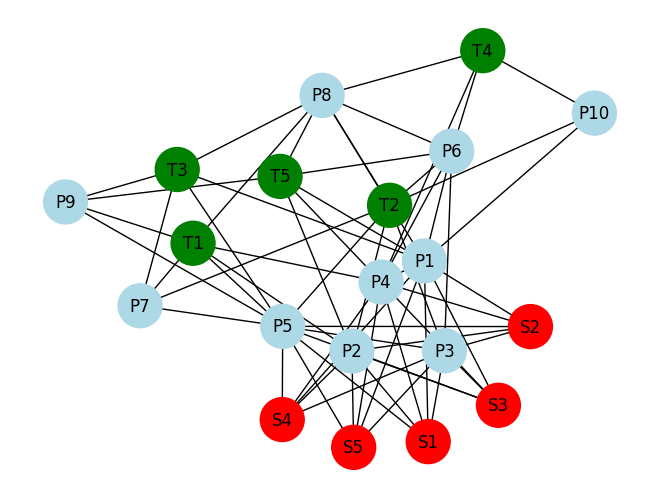

In [ ]:
import networkx as nx
import random
import matplotlib.pyplot as plt

# Criar grafo gigante
G_gigante = nx.Graph()

# === Sources (vermelho) ===
for i in range(1, 6):
    G_gigante.add_node(f"S{i}", tipo="source", cor="red")

# === Pontos de passagem (azul claro) ===
for i in range(1, 11):
    G_gigante.add_node(f"P{i}", tipo="passagem", cor="lightblue")

# === Sinks (verde) ===
for i in range(1, 6):
    G_gigante.add_node(f"T{i}", tipo="sink", cor="green")

# === Ligar sources a pontos de passagem ===
for s in range(1, 6):
    for p in range(1, 6):  # cada source liga a 5 passagens
        G_gigante.add_edge(f"S{s}", f"P{p}", capacidade=random.randint(2, 6))

# === Ligar pontos de passagem entre si ===
for i in range(1, 11):
    for j in range(i+1, 11):
        if random.random() < 0.3:  # 30% de probabilidade de haver ligação
            G_gigante.add_edge(f"P{i}", f"P{j}", capacidade=random.randint(1, 4))

# === Ligar passagens a sinks ===
for p in range(1, 11):
    for t in range(1, 6):
        if random.random() < 0.5:  # 50% probabilidade de ligação
            G_gigante.add_edge(f"P{p}", f"T{t}", capacidade=random.randint(2, 7))

# === Encomenda gigante (50 pacotes aleatórios) ===
tipos_pacotes = [1, 2, 5]  # tipos standard
pacotes_gigantes = []
for _ in range(50):
    tam = random.choice(tipos_pacotes)
    origem = f"S{random.randint(1, 5)}"
    destino = f"T{random.randint(1, 5)}"
    pacotes_gigantes.append({"tamanho": tam, "origem": origem, "destino": destino})

stock_sinks_gigantes = {f"T{i}": random.randint(20, 50) for i in range(1, 6)}

pos = nx.spring_layout(G_gigante)

color_map = []
for node in G_gigante:
  color_map.append(G_gigante.nodes[node]['cor'])

nx.draw(G_gigante, pos, with_labels=True, node_color=color_map, node_size=1000)

resultados_gigante = resolver_distribuicao_melhorado(G_gigante, [(p['tamanho'], p['origem'], p['destino']) for p in pacotes_gigantes], stock_sinks_gigantes)
if resultados_gigante:
  printResultados(resultados_gigante)
else:
  print("Sem Solução")